In [1]:
# numpy == 1.21.5
import numpy as np
# scipy == 1.7.3
import scipy.linalg
# to make nice plots
import matplotlib.pyplot as plt
# optional -- to track how long a simulation will| take
from tqdm import tqdm

from steinberg_utils_3vertex import *
from steinberg import (
    spectrum_any, normalization_factors, projection_matrices, B_matrix, skew_symmetric_area, 
    steinberg_analytical_area, check_Lk, is_zero_at_eq, check_analytical_numerical_consistency
)

In [2]:
# plot formatting
plt.rc("text", usetex=False) # renders LaTeX more quickly
plt.rc("font", family = "serif",size=14) # font specifications
plt.rc("figure",figsize=(14,12)) # figure size
%config InlineBackend.figure_format = 'retina' # retina-display quality

How to compute numerical area

In [3]:
np.random.seed(42)
params = random_parameters()
lap = Laplacian_K(params)
signal = [3, 5, 7]
tau, _ = define_tau_range(lap)

a_13, a_31 = asymmetric_autocorrelation(signal, lap, tau)

v1 = np.abs(np.trapezoid(a_13, tau) - np.trapezoid(a_31, tau))
v2 = np.abs(np.trapezoid(a_13 - a_31, tau))

print(f"v1 (separate): {v1:.6e}")
print(f"v2 (difference): {v2:.6e}")
print(f"match: {np.isclose(v1, v2)}")

v1 (separate): 9.991083e-04
v2 (difference): 9.991083e-04
match: True


Is B(G) correct at equilibrium?

In [4]:
np.random.seed(42)
params = equilibrium_parameters()
lap = Laplacian_K(params)
signal = [3, 5, 7]
area = steinberg_analytical_area(signal, lap)
print(f"Signature at equilibrium: {area:.6e}  (should be ~0)")

Signature at equilibrium: 9.551178e-09  (should be ~0)


Does the analytical area match the numerical area?

In [11]:
np.random.seed(42)
params = random_parameters()
lap = Laplacian_K(params)
signal = [3, 5, 7]
tau, tau_max = define_tau_range(lap, max_points=5000, cap_factor=50.0)
tau = np.linspace(0, tau_max, num=5000)
a_13, a_31 = asymmetric_autocorrelation(signal, lap, tau)
numerical = numerical_area(a_13, a_31, tau)
print(f"numerical (cap=50): {numerical:.6e}")
print(f"analytical:         {analytical:.6e}")

numerical (cap=50): 1.028867e-03
analytical:         1.030044e-03


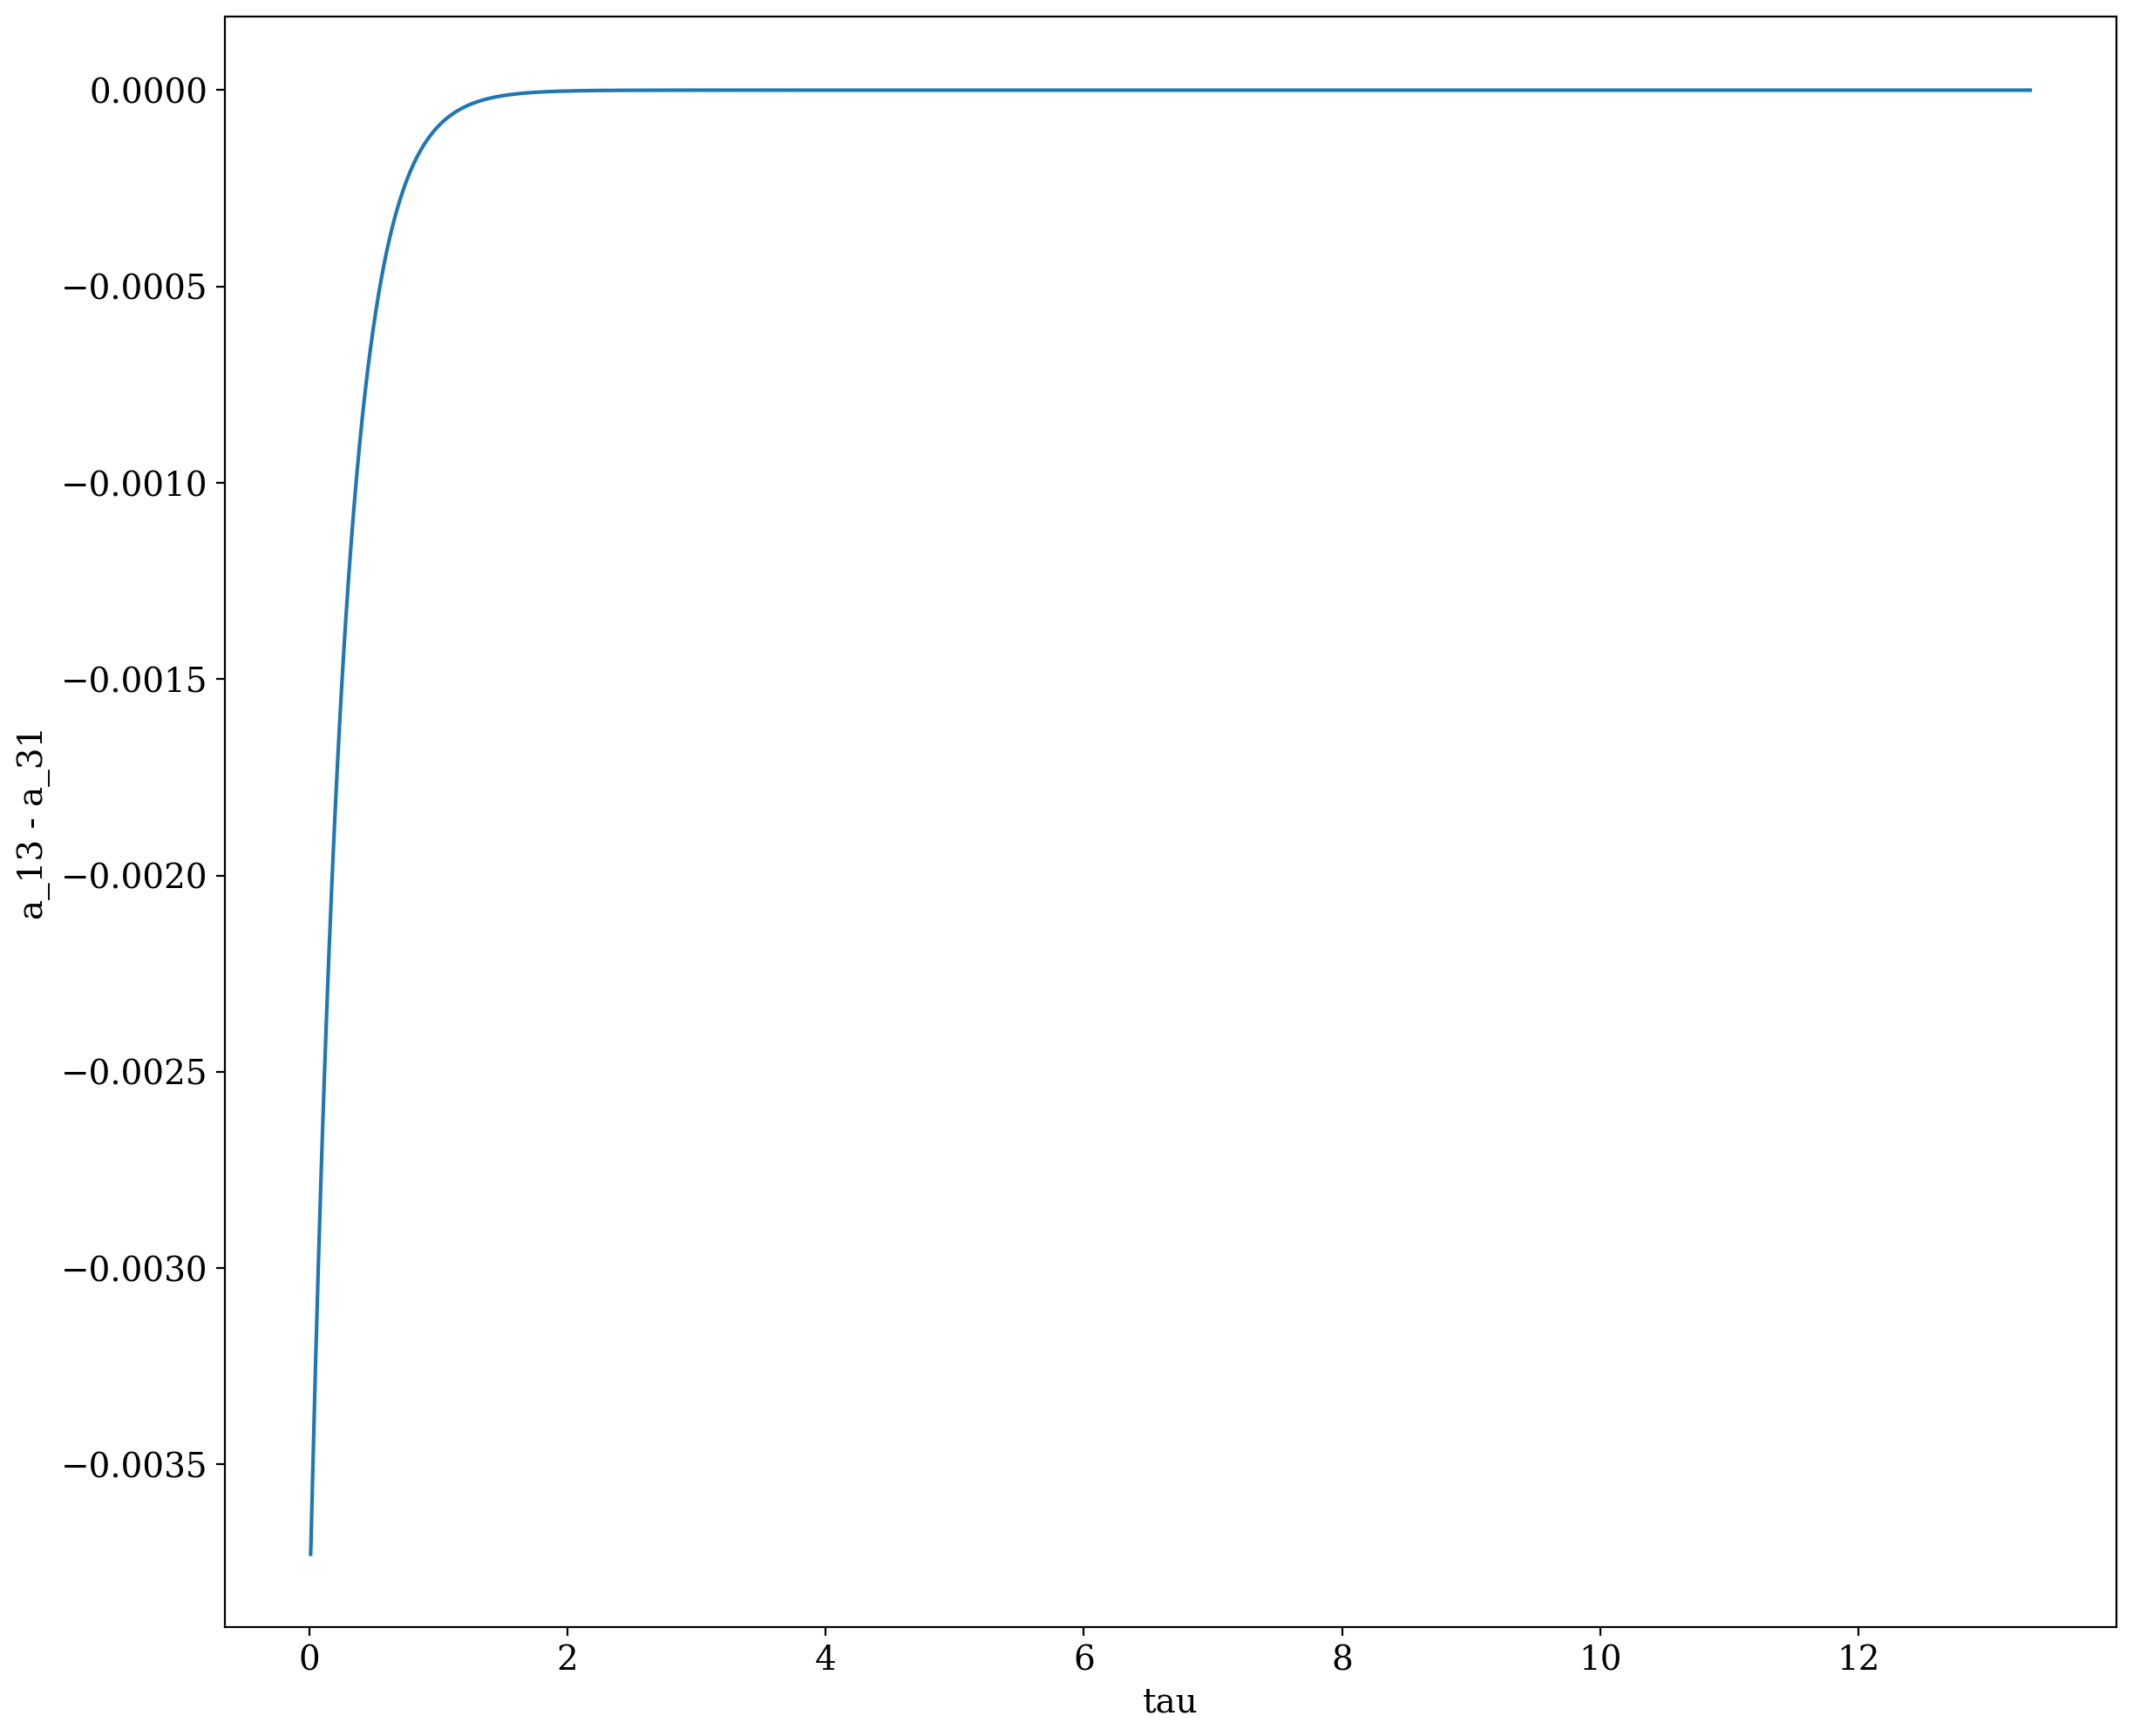

value at tau=0.01: -3.728552e-03
value at tau_max:  -2.842171e-14


In [8]:
tau, _ = define_tau_range(lap, max_points=5000, cap_factor=50.0)
a_13, a_31 = asymmetric_autocorrelation(signal, lap, tau)

plt.plot(tau, a_13 - a_31)
plt.xlabel('tau')
plt.ylabel('a_13 - a_31')
plt.show()

print(f"value at tau=0.01: {(a_13-a_31)[0]:.6e}")
print(f"value at tau_max:  {(a_13-a_31)[-1]:.6e}")


In [10]:
np.random.seed(42)
params = random_parameters()
lap = Laplacian_K(params)
signal = [3, 5, 7]

lambdas, w_i, z_i = spectrum_any(lap)
r_i = normalization_factors(w_i, z_i)
Lk_list = projection_matrices(w_i, z_i, r_i)
pi = np.array(pi_dist(lap))
delta_u_star = np.diag(pi)

print(f"lambdas: {lambdas}")
print(f"r_i: {r_i}")
print(f"pi: {pi}")
print(f"sum(Lk_list) == I: {np.allclose(sum(Lk_list), np.eye(3))}")

lambdas: [-5.31211144e+02+0.j -3.75081740e+00+0.j  4.77936856e-16+0.j]
r_i: [0.72387026+0.j 0.70737852+0.j 0.58015874+0.j]
pi: [9.95148946e-01 3.64271490e-04 4.48678204e-03]
sum(Lk_list) == I: True


In [11]:
np.random.seed(42)
params = random_parameters()
lap = Laplacian_K(params)
signal = [3, 5, 7]
tau, _ = define_tau_range(lap)

a_13, a_31 = asymmetric_autocorrelation(signal, lap, tau)
numerical = numerical_area(a_13, a_31, tau)
analytical = steinberg_analytical_area(signal, lap)

print(f"numerical:  {numerical:.6e}")
print(f"analytical: {analytical:.6e}")

numerical:  9.991083e-04
analytical: 7.324736e-06
